Saving fashion_data_2018_2022.xls to fashion_data_2018_2022.xls
First 5 Rows
   product_id    product_name  gender category     pattern  color age_group  \
0        1001    Biker Jacket    Male    Shirt   Geometric  White     25-35   
1        1002  Business Shirt    Male   Jacket  Polka Dots  Beige     18-24   
2        1003     Wool Jacket  Female    Dress   Geometric  Brown     18-24   
3        1004    Summer Dress    Male   Shorts       Plain  White     25-35   
4        1005    Casual Jeans    Male    Shirt       Plain  Beige     35-45   

   season   price   material  sales_count  reviews_count  average_rating  \
0  Spring   70.36  Synthetic           75             65             4.9   
1  Summer   91.59       Wool          296             25             3.5   
2     All  129.52       Wool           50             32             4.3   
3     All  116.01     Cotton          435             73             4.6   
4  Winter  125.48    Viscose           79             36            

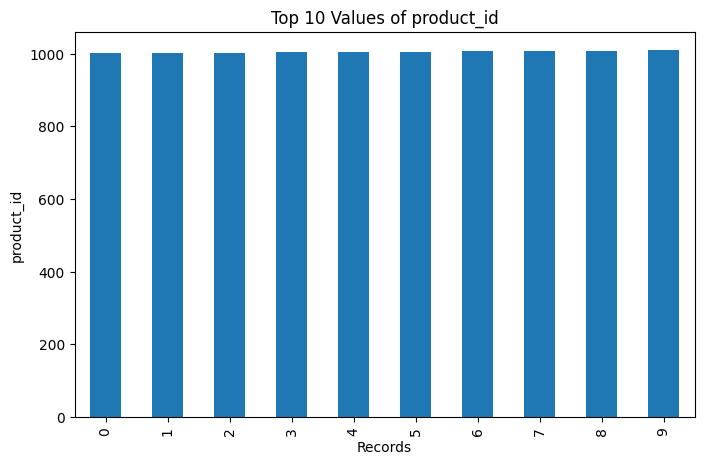

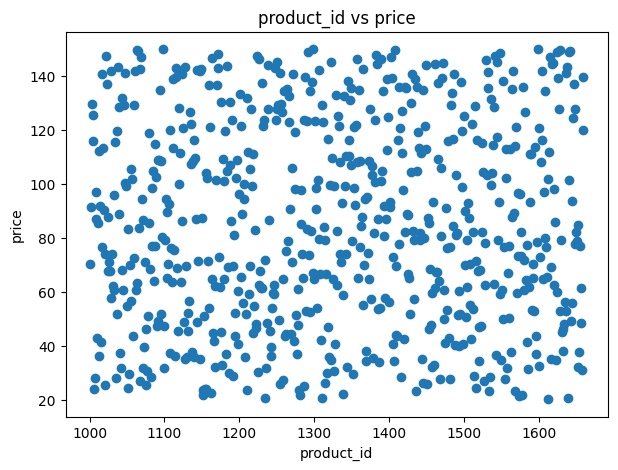

In [1]:
!pip install -q xlrd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nStatistics")
print(df.describe())

num_cols = df.select_dtypes(include="number").columns

if len(num_cols) > 0:
    filtered = df[df[num_cols[0]] > df[num_cols[0]].mean()]
    print("\nFiltered Data")
    print(filtered.head())

if len(num_cols) > 0:
    sorted_df = df.sort_values(by=num_cols[0], ascending=False)
    print("\nSorted Data")
    print(sorted_df.head())

for col in num_cols:
    print("\nColumn:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Standard Deviation:", df[col].std())

cat_cols = df.select_dtypes(include="object").columns

if len(cat_cols) > 0 and len(num_cols) > 0:
    grouped = df.groupby(cat_cols[0])[num_cols].mean()
    print("\nGrouped Data")
    print(grouped)

if len(num_cols) > 1:
    corr = df[num_cols].corr()
    print("\nCorrelation Matrix")
    print(corr)

if len(num_cols) > 0:
    plt.figure(figsize=(8,5))
    df[num_cols[0]].head(10).plot(kind="bar")
    plt.title("Top 10 Values of " + num_cols[0])
    plt.xlabel("Records")
    plt.ylabel(num_cols[0])
    plt.show()

if len(num_cols) >= 2:
    plt.figure(figsize=(7,5))
    plt.scatter(df[num_cols[0]], df[num_cols[1]])
    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.title(num_cols[0] + " vs " + num_cols[1])
    plt.show()